## Waste Classification

In [3]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [4]:
train_path = "DATASET/TRAIN"
test_path = "DATASET/TEST"

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Activation , Dropout , Flatten , Dense , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator , img_to_array , load_img
from tensorflow.keras.utils import plot_model
from glob import glob

In [6]:
#Visualization 
from cv2 import cvtColor
x_data = []
y_data = []
for category in glob(train_path+'/*'):
     for file in tqdm(glob(category+'/*')):
        img_array = cv2.imread(file)
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
        x_data.append(img_array)
        y_data.append(category.split('/')[-1])
data = pd.DataFrame({'image': x_data , 'label': y_data})       

100%|██████████| 9999/9999 [00:15<00:00, 632.29it/s] 


In [7]:
data.shape

(22564, 2)

<function matplotlib.pyplot.show(close=None, block=None)>

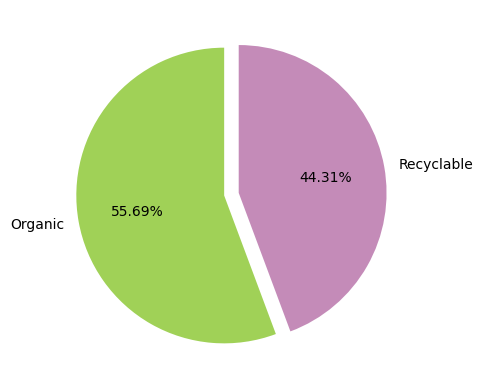

In [8]:
colors = ['#a0d157' , '#c48bb8']
plt.pie(data.label.value_counts() , labels =['Organic' , 'Recyclable'] , autopct='%0.2f%%' , colors=colors , startangle=90 , explode=[0.05 , 0.05])
plt.show

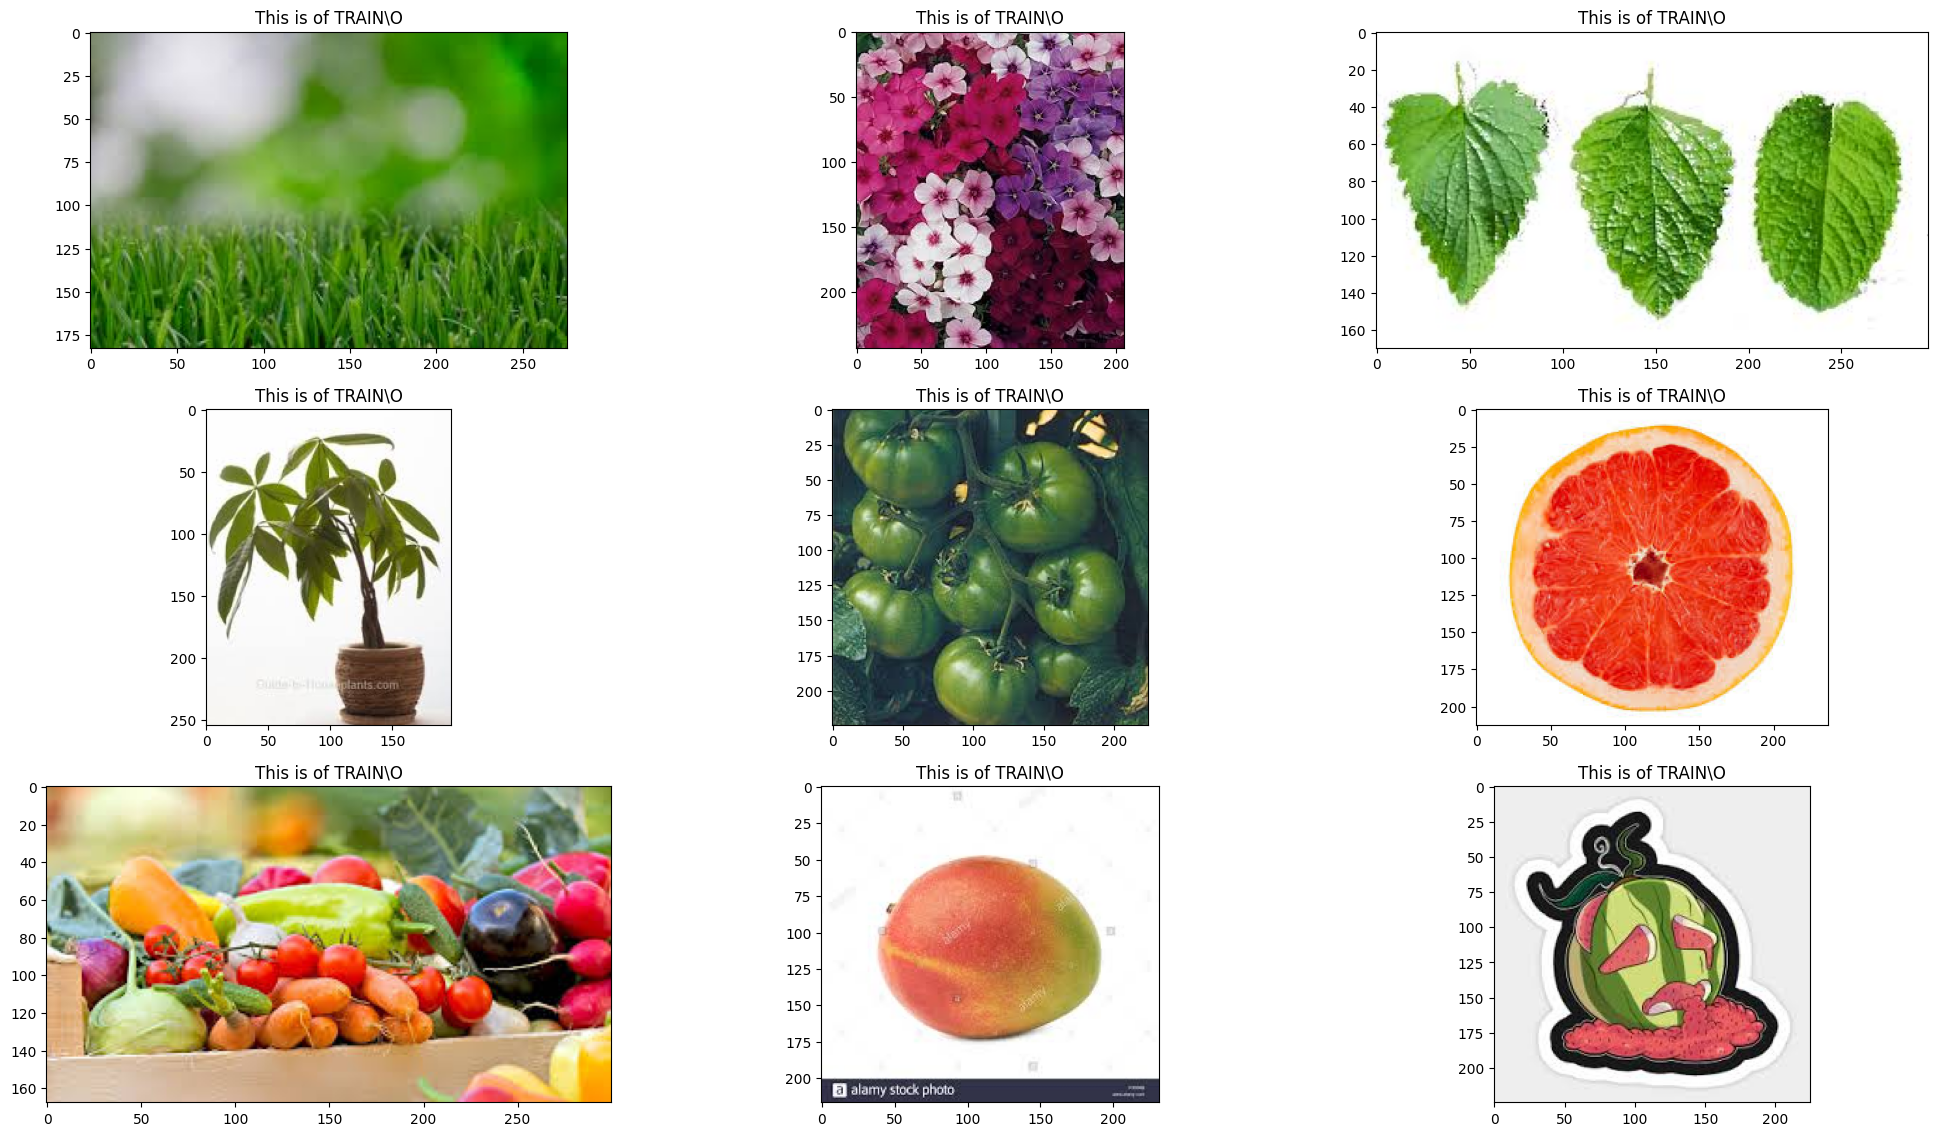

In [9]:
plt.figure(figsize=(20, 15))
for i in range(9):
    plt.subplot(4, 3, (i%12)+1)
    index = np.random.randint(15000)
    plt.title('This is of {0}'.format(data.label[index]))
    plt.imshow(data.image[index])
    plt.tight_layout()

## CNN - Convolutional Neural Network

In [10]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , input_shape = (224,224,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Conv2D(64 , (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128 , (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(2))
model.add(Activation('sigmoid'))

model.compile(loss = "binary_crossentropy" , 
              optimizer='adam',
              metrics=['accuracy'])
batch_size = 64


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,261,250 (84.92 MB)

 Trainable params: 22,261,250 (84.92 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
train_dategen = ImageDataGenerator(rescale= 1./255)

In [13]:
test_datagen = ImageDataGenerator(rescale= 1./255)

In [14]:
train_generator = train_dategen.flow_from_directory(
    train_path,
    target_size = (224,224),
    batch_size = batch_size,
    color_mode = "rgb",
        class_mode = "categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size = (224,224),
    batch_size = batch_size,
    color_mode = "rgb",
        class_mode = "categorical"
)

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [15]:
hist = model.fit(
    train_generator,
    epochs = 10,
    validation_data = test_generator
)

Epoch 1/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 601s 2s/step - accuracy: 0.7728 - loss: 0.5398 - val_accuracy: 0.8754 - val_loss: 0.3091
Epoch 2/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.8468 - loss: 0.3842 - val_accuracy: 0.8830 - val_loss: 0.3099
Epoch 3/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.8610 - loss: 0.3455 - val_accuracy: 0.8902 - val_loss: 0.2666
Epoch 4/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.8772 - loss: 0.3118 - val_accuracy: 0.8862 - val_loss: 0.2923
Epoch 5/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.8904 - loss: 0.2791 - val_accuracy: 0.8989 - val_loss: 0.2713
Epoch 6/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.9032 - loss: 0.2471 - val_accuracy: 0.9017 - val_loss: 0.2912
Epoch 7/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 557s 2s/step - accuracy: 0.9282 - loss: 0.1895 - val_accuracy: 0.9140 - val_loss: 0.2688
Epoch 8/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.9443 - loss: 0.1501 - val_accu

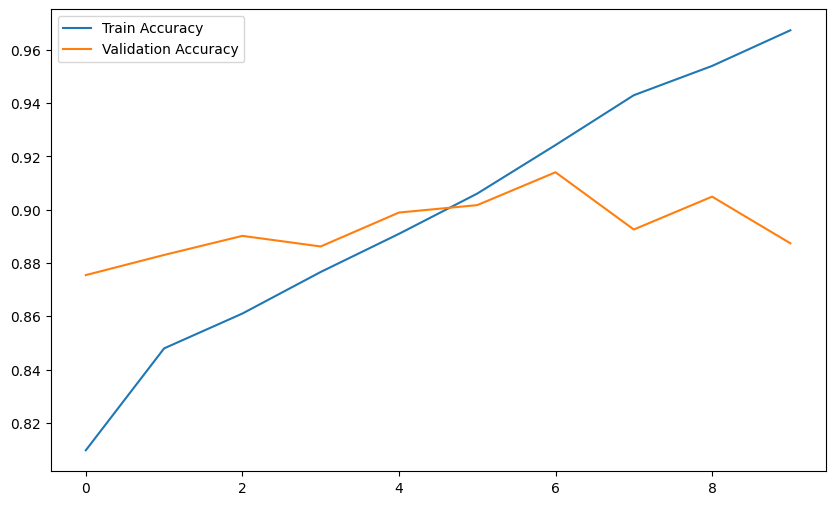

In [16]:
plt.figure(figsize=(10,6))
plt.plot(hist.history['accuracy'],label='Train Accuracy')
plt.plot(hist.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.show()

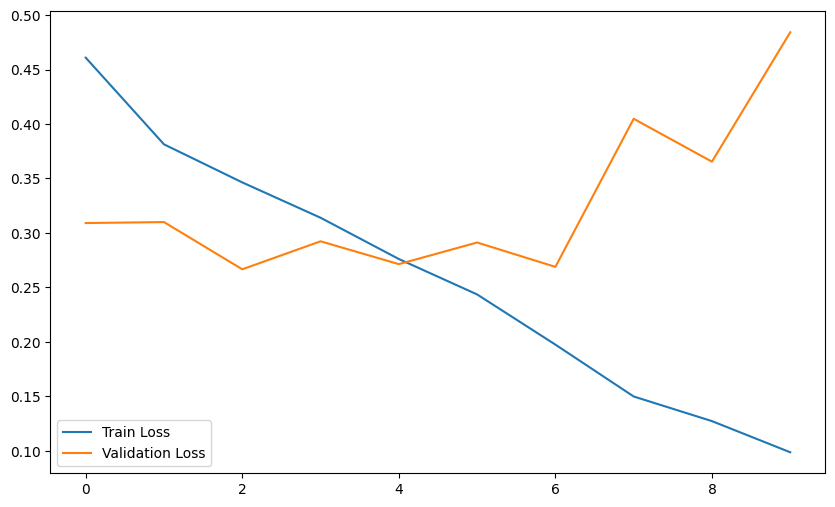

In [17]:
plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'],label='Train Loss')
plt.plot(hist.history['val_loss'],label='Validation Loss')
plt.legend()
plt.show()

In [21]:
def predict_fun(img):
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    img = cv2.resize(img,(224,224))
    img = np.reshape(img,[-1,224,224,3])
    result = np.argmax(model.predict(img))
    if result == 0:
        print('The Image Shown is Recyclable Waste')
    elif result == 1:
        print('The Image Shown is Organic Waste')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
The Image Shown is Organic Waste


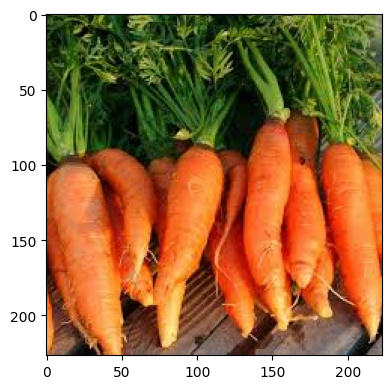

In [22]:
test_img = cv2.imread('D:\Prgrms\Vs Code\Waste Classification\DATASET\TEST\O\O_12568.jpg')
predict_fun(test_img)

In [1]:
model.save("waste_classifier_model.h5")

NameError: name 'model' is not defined